In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [6]:
# -------------------------
# 1. 读取并处理CSV文件
# -------------------------

# 读取两个CSV文件
csv1 = './wt.csv' # 替换为你的csv1文件路径
csv2 = './hy.csv' # 替换为你的csv2文件路径
# csv3 = './lanew.csv'
# 假设CSV文件包含 'operon1', 'operon2', 'expression1', 'expression2' 列
df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)
# df3 = pd.read_csv(csv3)
# 复制数据以避免修改原始数据
merged_filtered1 = df1.copy()
merged_filtered2 = df2.copy()
# merged_filtered3 = df3.copy()
print(merged_filtered1)
print(merged_filtered2)
# print(merged_filtered3)

          V1        V2
0   1.038589  0.935022
1   1.760000  1.937500
2   0.539286  0.563945
3   8.617925  9.313953
4   3.987695  4.277504
..       ...       ...
56  3.934109  3.595080
57  3.246032  3.595080
58  3.246032  3.212946
59  3.267030  3.595080
60  3.267030  3.212946

[61 rows x 2 columns]
          V1        V2
0   0.358875  0.621145
1   0.525333  1.046448
2   0.264286  1.072419
3   2.000884  5.210963
4   3.074586  2.886700
..       ...       ...
56  1.819239  0.643726
57  2.226190  0.643726
58  2.226190  0.628518
59  0.786104  0.643726
60  0.786104  0.628518

[61 rows x 2 columns]


R²1: 0.9933
R²2: 0.0431


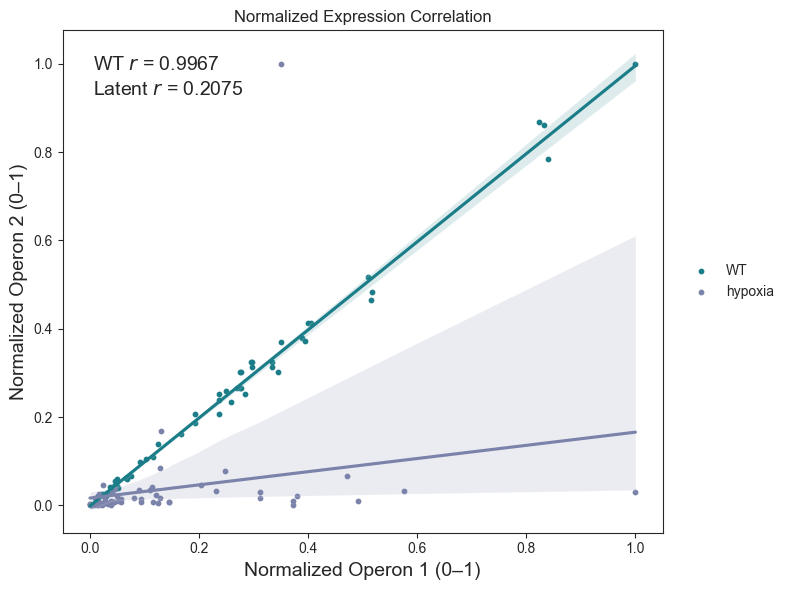

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ========= 1. 定义归一化函数 =========
def minmax_norm(df, cols):
    df_norm = df.copy()
    for c in cols:
        df_norm[c] = (df[c] - df[c].min()) / (df[c].max() - df[c].min())
    return df_norm

# ========= 2. 对每个组分别归一化 =========
merged_filtered1_norm = minmax_norm(merged_filtered1, ['V1', 'V2'])
merged_filtered2_norm = minmax_norm(merged_filtered2, ['V1', 'V2'])
# merged_filtered3_norm = minmax_norm(merged_filtered3, ['V1', 'V2'])

# ========= 3. 绘图 =========
sns.set_style("ticks")
plt.figure(figsize=(8, 6))

color1 = '#1B7D88'
# color3 = "#CC5536"
# color2 = "#EBA48F"
color2 = '#7C83AA'
s = 10
alpha = 1

sns.regplot(
    data=merged_filtered1_norm,
    x='V1', y='V2',
    scatter_kws={'s':s, 'alpha':alpha, 'color': color1},
    line_kws={'color': color1},
    label='WT'
)

sns.regplot(
    data=merged_filtered2_norm,
    x='V1', y='V2',
    scatter_kws={'s':s, 'alpha':alpha, 'color': color2},
    line_kws={'color': color2},
    label='hypoxia'
)

# sns.regplot(
#     data=merged_filtered3_norm,
#     x='V1', y='V2',
#     scatter_kws={'s':s, 'alpha':alpha, 'color': color3},
#     line_kws={'color': color3},
#     label='hypoxia_new'
# )

plt.xlabel('Normalized Operon 1 (0–1)', fontsize=14)
plt.ylabel('Normalized Operon 2 (0–1)', fontsize=14)
plt.title('Normalized Expression Correlation')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# ========= 4. 计算 R² =========
def calc_r2(df):
    X = df['V1'].values.reshape(-1, 1)
    y = df['V2'].values
    model = LinearRegression().fit(X, y)
    return r2_score(y, model.predict(X))

r_squared1 = calc_r2(merged_filtered1_norm)
r_squared2 = calc_r2(merged_filtered2_norm)
# r_squared3 = calc_r2(merged_filtered3_norm)

print(f"R²1: {r_squared1:.4f}")
print(f"R²2: {r_squared2:.4f}")
# print(f"R²3: {r_squared3:.4f}")

# ========= 5. 计算 Pearson r =========
r1 = merged_filtered1_norm[['V1','V2']].corr().iloc[0,1]
r2 = merged_filtered2_norm[['V1','V2']].corr().iloc[0,1]
# r3 = merged_filtered3_norm[['V1','V2']].corr().iloc[0,1]

# ========= 6. 标注 =========
plt.text(0.05, 0.95, f'WT $r$ = {r1:.4f}', transform=plt.gca().transAxes, fontsize=14, va='top')
plt.text(0.05, 0.90, f'Latent $r$ = {r2:.4f}', transform=plt.gca().transAxes, fontsize=14, va='top')
# plt.text(0.05, 0.85, f'Latent-new $r$ = {r3:.4f}', transform=plt.gca().transAxes, fontsize=14, va='top')

plt.tight_layout()
plt.savefig('normalized_hypoxia_superoperon_exp_cor_.pdf')
plt.show()

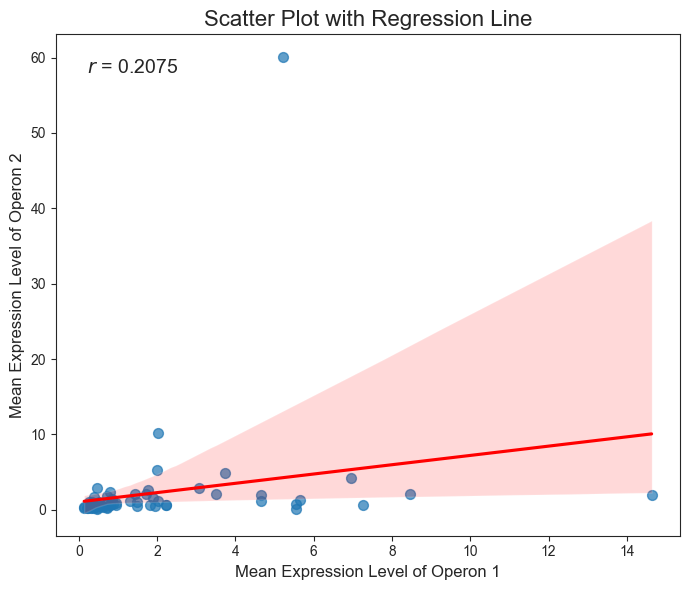

In [4]:
df = pd.read_csv('hy.csv')
# 设置绘图风格
sns.set_style("ticks")  # 其他可选样式包括 "ticks"

# 绘制散点图并添加回归曲线
plt.figure(figsize=(7, 6))

# 使用 Seaborn 的 regplot 绘制带回归线的散点图
sns.regplot(data=df, x='V1', y='V2', 
            scatter_kws={'s':50, 'alpha':0.7}, line_kws={'color':'red'})

# 设置轴标签和标题
plt.xlabel('Mean Expression Level of Operon 1', fontsize=12)
plt.ylabel('Mean Expression Level of Operon 2', fontsize=12)
plt.title('Scatter Plot with Regression Line', fontsize=16)
r=df.corr(method='pearson',min_periods=1)
# 标注 R² 值
plt.text(0.05, 0.95, f'$r$ = {r.iloc[0,1]:.4f}', transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top')

# 显示图形
plt.tight_layout()
plt.savefig('hypoxia_superoperon_exp_cor.pdf',format='pdf')
plt.show()